# EchoMind — Multimodal Fusion v4 FINAL

Pipeline final do EchoMind com integração do novo módulo de prosódia v4.

Fluxo:

1. áudio do diário emocional;
2. transcrição com Whisper;
3. emoção por texto com Qwen/Ollama Advanced_V2;
4. emoção por prosódia com artefacto `prosody_final_artifact_v4.joblib`;
5. late fusion adaptativa entre texto e prosódia;
6. output completo com transcrição, distribuições, ranking, pesos e incerteza.

O notebook é compatível com o artefacto novo v4, mas mantém fallback parcial para artefactos antigos quando possível.

In [56]:
# ============================================================
# 1. Instalação de dependências
# ============================================================
# Em ambiente novo, descomenta conforme necessário.
# A primeira execução com Whisper/WavLM pode precisar de internet para descarregar modelos.



import sys

!{sys.executable} -m pip install -U numpy pandas matplotlib tqdm joblib scikit-learn librosa soundfile requests torch transformers accelerate openai-whisper praat-parselmouth ffmpeg-python

print("✅ Célula de instalação pronta.")


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 11.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 11.3 MB/s  0:00:00eta 0:00:01
  Attempting uninstall: requests
    Found existing installation: requests 2.33.0
    Uninstalling requests-2.33.0:
      Successfully uninstalled requests-2.33.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [scikit-learn]
    Found existing installation: pandas 2.2.3━━━━━━━━━━━━━━━━━ 1/5 [scikit-learn]
    Uninstalling pandas-2.2.3:90m╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [pandas]n]


In [57]:
# ============================================================
# 2. Imports e configuração global
# ============================================================

import os
import re
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib
import requests

import librosa

try:
    import whisper
    WHISPER_AVAILABLE = True
except Exception as e:
    print("⚠️ whisper indisponível. Podes usar transcript_override.", repr(e))
    whisper = None
    WHISPER_AVAILABLE = False

try:
    import torch
    from transformers import AutoFeatureExtractor, AutoModel
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    print("⚠️ torch/transformers indisponível. O ramo SSL da prosódia só funciona se não for necessário.", repr(e))
    torch = None
    AutoFeatureExtractor = None
    AutoModel = None
    TRANSFORMERS_AVAILABLE = False

try:
    import parselmouth
    PARSELMOUTH_AVAILABLE = True
except Exception:
    PARSELMOUTH_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

EMOTIONS = ["joy", "sadness", "surprise", "fear", "anger", "disgust", "neutral"]
TARGET_SR = 16000
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac", ".webm"}

AUDIO_DIR = Path(os.environ.get("AUDIO_DIR", "audios_teste"))
OUTPUT_DIR = Path("multimodal_outputs_v4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROSODY_MODEL_PATH = Path(os.environ.get("PROSODY_MODEL_PATH", "prosody_outputs_v4/prosody_final_artifact_v4.joblib"))
# Fallbacks úteis:
PROSODY_FALLBACK_PATHS = [
    PROSODY_MODEL_PATH,
    Path("prosody_outputs_v4/prosody_final_pipeline_v4.joblib"),
    Path("prosody_outputs_v3/prosody_final_pipeline_v3.joblib"),
    Path("prosody_final_pipeline.joblib"),
]

TEXT_MODEL = os.environ.get("TEXT_MODEL", "qwen2.5:3b-instruct")
OLLAMA_URL = os.environ.get("OLLAMA_URL", "http://127.0.0.1:11434/api/generate")
WHISPER_MODEL_NAME = os.environ.get("WHISPER_MODEL_NAME", "small")

# Desempenho empírico usado como prior da fusão.
TEXT_RELIABILITY = 0.788
DEFAULT_PROSODY_RELIABILITY = 0.45

print("📁 AUDIO_DIR:", AUDIO_DIR.resolve())
print("📦 PROSODY_MODEL_PATH:", PROSODY_MODEL_PATH)
print("🧠 TEXT_MODEL:", TEXT_MODEL)


📁 AUDIO_DIR: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/audios_teste
📦 PROSODY_MODEL_PATH: prosody_outputs_v4/prosody_final_artifact_v4.joblib
🧠 TEXT_MODEL: qwen2.5:3b-instruct


In [58]:
# ============================================================
# 3. Descobrir áudios e labels esperadas pelos nomes
# ============================================================

FILENAME_TO_EXPECTED = {
    "joy": "joy", "alegria": "joy", "happy": "joy", "happiness": "joy",
    "sadness": "sadness", "sad": "sadness", "tristeza": "sadness",
    "surprise": "surprise", "surpresa": "surprise",
    "fear": "fear", "medo": "fear",
    "anger": "anger", "angry": "anger", "raiva": "anger",
    "disgust": "disgust", "nojo": "disgust",
    "neutral": "neutral", "neutro": "neutral",
}


def infer_expected_from_filename(path: Path) -> Optional[str]:
    stem = re.sub(r"[^a-zA-Z0-9]+", " ", path.stem.lower())
    tokens = stem.split()
    for tok in tokens + [path.stem.lower()]:
        if tok in FILENAME_TO_EXPECTED:
            return FILENAME_TO_EXPECTED[tok]
    return None


def discover_audio_files(audio_dir: Path = AUDIO_DIR) -> List[Path]:
    if not audio_dir.exists():
        print(f"⚠️ Pasta não existe: {audio_dir.resolve()}")
        return []
    files = [p for p in sorted(audio_dir.rglob("*")) if p.is_file() and p.suffix.lower() in AUDIO_EXTS]
    print(f"✅ Áudios encontrados: {len(files)}")
    return files

AUDIO_FILES = discover_audio_files(AUDIO_DIR)
if AUDIO_FILES:
    display(pd.DataFrame([{"file": p.name, "expected": infer_expected_from_filename(p), "path": str(p)} for p in AUDIO_FILES]))


✅ Áudios encontrados: 7


,file,expected,path
0,anger.wav,anger,audios_teste/anger.wav
1,disgust.wav,disgust,audios_teste/disgust.wav
2,fear.wav,fear,audios_teste/fear.wav
3,joy.wav,joy,audios_teste/joy.wav
4,neutral.wav,neutral,audios_teste/neutral.wav
5,sad.wav,sadness,audios_teste/sad.wav
6,surprise.wav,surprise,audios_teste/surprise.wav


In [59]:
# ============================================================
# 4. Whisper — carregamento lazy e transcrição
# ============================================================

_whisper_model = None


def load_whisper_model(model_name: str = WHISPER_MODEL_NAME):
    global _whisper_model
    if not WHISPER_AVAILABLE:
        raise RuntimeError("openai-whisper não está instalado. Instala ou usa transcript_override.")
    if _whisper_model is None:
        print(f"🎧 A carregar Whisper: {model_name}")
        _whisper_model = whisper.load_model(model_name)
    return _whisper_model


def transcribe_audio(audio_path: str | Path, language: str = "pt") -> str:
    model = load_whisper_model()
    result = model.transcribe(str(audio_path), language=language, fp16=False)
    text = (result.get("text") or "").strip()
    return text

print("✅ Funções Whisper prontas.")


✅ Funções Whisper prontas.


In [60]:
# ============================================================
# 5. Qwen Advanced_V2 via Ollama
# ============================================================


def normalize_vector(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.clip(p, 0.0, None)
    s = float(p.sum())
    if s <= 0:
        return np.ones_like(p) / len(p)
    return p / s


def normalize_distribution(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> Dict[str, float]:
    p = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    p = normalize_vector(p)
    return {e: float(p[i]) for i, e in enumerate(emotions)}


def parse_json_distribution(text: str) -> Dict[str, float]:
    raw = text.strip()
    # Remove blocos markdown se existirem.
    raw = re.sub(r"^```(?:json)?", "", raw).strip()
    raw = re.sub(r"```$", "", raw).strip()
    match = re.search(r"\{.*\}", raw, flags=re.S)
    if not match:
        raise ValueError(f"Não encontrei JSON na resposta: {text[:300]}")
    obj = json.loads(match.group(0))
    if "distribution" in obj and isinstance(obj["distribution"], dict):
        obj = obj["distribution"]
    return normalize_distribution({e: float(obj.get(e, 0.0)) for e in EMOTIONS})


def check_ollama(timeout: float = 3.0) -> bool:
    try:
        r = requests.post(
            OLLAMA_URL,
            json={"model": TEXT_MODEL, "prompt": "Responde apenas OK.", "stream": False, "options": {"temperature": 0.0}},
            timeout=timeout,
        )
        return r.status_code == 200
    except Exception:
        return False


def build_advanced_v2_prompt(transcript: str) -> str:
    return f"""
És um classificador de emoções para diários emocionais em português europeu.

Tarefa: analisar a transcrição e devolver uma distribuição de probabilidade pelas seguintes 7 emoções:
joy, sadness, surprise, fear, anger, disgust, neutral.

Regras:
- Devolve APENAS JSON válido.
- As 7 chaves devem estar sempre presentes.
- Os valores devem estar entre 0 e 1.
- A soma deve ser aproximadamente 1.
- Não expliques o raciocínio.
- Usa "neutral" quando o texto é factual, ambíguo ou sem carga emocional forte.
- Não confundas cansaço/calmo com tristeza automaticamente.
- Se houver mistura emocional, distribui a probabilidade.

Exemplos:
Texto: "Hoje recebi uma notícia excelente e fiquei mesmo contente."
JSON: {{"joy":0.78,"sadness":0.03,"surprise":0.10,"fear":0.02,"anger":0.02,"disgust":0.01,"neutral":0.04}}

Texto: "Fiquei revoltado porque senti que fui tratado de forma injusta."
JSON: {{"joy":0.02,"sadness":0.12,"surprise":0.03,"fear":0.04,"anger":0.70,"disgust":0.06,"neutral":0.03}}

Texto: "Hoje não aconteceu nada de especial, foi um dia normal."
JSON: {{"joy":0.08,"sadness":0.05,"surprise":0.02,"fear":0.02,"anger":0.02,"disgust":0.01,"neutral":0.80}}

Transcrição a analisar:
<TRANSCRICAO>
{transcript}
</TRANSCRICAO>

JSON:
""".strip()


def lexical_fallback_distribution(transcript: str) -> Dict[str, float]:
    """Fallback simples para não bloquear o notebook se o Ollama estiver desligado."""
    text = (transcript or "").lower()
    lex = {
        "joy": ["feliz", "contente", "alegre", "bom", "excelente", "gostei", "orgulho", "vitória"],
        "sadness": ["triste", "cansado", "sozinho", "chorei", "saudade", "desanimado", "perdi"],
        "surprise": ["surpres", "inesperado", "espantado", "chocado", "não esperava"],
        "fear": ["medo", "assustado", "ansioso", "preocupado", "receio", "pânico"],
        "anger": ["raiva", "irritado", "revoltado", "injusto", "farto", "zangado"],
        "disgust": ["nojo", "nojento", "repulsa", "vergonha", "ridículo"],
        "neutral": ["normal", "habitual", "rotina", "nada de especial"],
    }
    scores = np.ones(len(EMOTIONS)) * 0.08
    for i, emo in enumerate(EMOTIONS):
        for w in lex[emo]:
            if w in text:
                scores[i] += 0.25
    return {e: float(v) for e, v in zip(EMOTIONS, normalize_vector(scores))}


def classify_text_emotion(transcript: str, allow_fallback: bool = True) -> Dict[str, float]:
    prompt = build_advanced_v2_prompt(transcript)
    try:
        r = requests.post(
            OLLAMA_URL,
            json={
                "model": TEXT_MODEL,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0.1, "top_p": 0.9, "num_ctx": 4096},
            },
            timeout=120,
        )
        r.raise_for_status()
        raw = r.json().get("response", "")
        return parse_json_distribution(raw)
    except Exception as e:
        if allow_fallback:
            print("⚠️ Qwen/Ollama falhou; a usar fallback lexical simples.", repr(e))
            return lexical_fallback_distribution(transcript)
        raise

print("✅ Funções Qwen Advanced_V2 prontas.")


✅ Funções Qwen Advanced_V2 prontas.


In [61]:
# ============================================================
# 6. Extração acústica v4 compatível com o artefacto de prosódia
# ============================================================

TRIM_SILENCE = True
TOP_DB = 25
MIN_SECONDS = 0.75
N_SEGMENTS = 4
SSL_MAX_SECONDS_PER_CHUNK = 12.0
SSL_CHUNK_OVERLAP_SECONDS = 1.0


def load_audio(path: str | Path, target_sr: int = TARGET_SR) -> Tuple[np.ndarray, int]:
    y, sr = librosa.load(str(path), sr=target_sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    if TRIM_SILENCE and y.size > 0:
        y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    min_len = int(MIN_SECONDS * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    if np.max(np.abs(y)) > 0:
        y = y / max(1.0, float(np.max(np.abs(y))))
    return y.astype(np.float32), target_sr


def _safe_stats(prefix: str, values: np.ndarray, percentiles: bool = True) -> Dict[str, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    keys = ["mean", "std", "min", "max", "median", "range"]
    if percentiles:
        keys += ["p10", "p25", "p75", "p90", "iqr"]
    if values.size == 0:
        return {f"{prefix}_{k}": np.nan for k in keys}
    out = {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_range": float(np.max(values) - np.min(values)),
    }
    if percentiles:
        p10, p25, p75, p90 = np.percentile(values, [10, 25, 75, 90])
        out.update({f"{prefix}_p10": float(p10), f"{prefix}_p25": float(p25), f"{prefix}_p75": float(p75), f"{prefix}_p90": float(p90), f"{prefix}_iqr": float(p75-p25)})
    return out


def _pitch_features_librosa(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"), sr=sr, frame_length=2048, hop_length=256)
        voiced = f0[voiced_flag & np.isfinite(f0)] if voiced_flag is not None else np.array([])
        feats.update(_safe_stats(f"{prefix}_f0", voiced))
        feats[f"{prefix}_voiced_ratio"] = float(np.mean(voiced_flag)) if voiced_flag is not None and len(voiced_flag) else np.nan
        if voiced_prob is not None:
            feats.update(_safe_stats(f"{prefix}_voiced_prob", voiced_prob, percentiles=False))
    except Exception:
        feats.update(_safe_stats(f"{prefix}_f0", np.array([])))
        feats[f"{prefix}_voiced_ratio"] = np.nan
    return feats


def _pitch_features_parselmouth(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    if not PARSELMOUTH_AVAILABLE:
        return feats
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=50, pitch_ceiling=500)
        f0 = pitch.selected_array["frequency"]
        f0 = f0[f0 > 0]
        feats.update(_safe_stats(f"{prefix}_praat_f0", f0))
        point_process = parselmouth.praat.call(snd, "To PointProcess (periodic, cc)", 50, 500)
        local_jitter = parselmouth.praat.call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        local_shimmer = parselmouth.praat.call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        feats[f"{prefix}_jitter_local"] = float(local_jitter) if np.isfinite(local_jitter) else np.nan
        feats[f"{prefix}_shimmer_local"] = float(local_shimmer) if np.isfinite(local_shimmer) else np.nan
    except Exception:
        feats[f"{prefix}_jitter_local"] = np.nan
        feats[f"{prefix}_shimmer_local"] = np.nan
    return feats


def extract_manual_features_from_signal(y: np.ndarray, sr: int, prefix: str = "global") -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats[f"{prefix}_duration"] = float(len(y) / sr if sr else 0.0)
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=256)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=256)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=256)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=256)[0]
    flatness = librosa.feature.spectral_flatness(y=y, hop_length=256)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=256)
    for name, arr in [("rms", rms), ("zcr", zcr), ("centroid", centroid), ("bandwidth", bandwidth), ("rolloff", rolloff), ("flatness", flatness), ("onset", onset_env)]:
        feats.update(_safe_stats(f"{prefix}_{name}", arr))
    feats[f"{prefix}_low_energy_ratio"] = float(np.mean(rms < np.percentile(rms, 25) * 0.75)) if len(rms) else np.nan
    try:
        tempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr, hop_length=256)
        feats[f"{prefix}_tempo"] = float(np.ravel(tempo)[0]) if len(np.ravel(tempo)) else np.nan
    except Exception:
        feats[f"{prefix}_tempo"] = np.nan
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=256)
    for i in range(mfcc.shape[0]):
        feats.update(_safe_stats(f"{prefix}_mfcc{i+1}", mfcc[i], percentiles=False))
    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=256)
        for i in range(chroma.shape[0]):
            feats.update(_safe_stats(f"{prefix}_chroma{i+1}", chroma[i], percentiles=False))
    except Exception:
        pass
    feats.update(_pitch_features_librosa(y, sr, prefix))
    if prefix == "global":
        feats.update(_pitch_features_parselmouth(y, sr, prefix))
    return feats


def extract_manual_features_from_file(path: str | Path, audio_id: Optional[str] = None) -> Dict[str, float]:
    y, sr = load_audio(path, TARGET_SR)
    feats = {"audio_id": audio_id if audio_id is not None else Path(path).stem, "duration_sec": float(len(y) / sr)}
    feats.update(extract_manual_features_from_signal(y, sr, prefix="global"))
    seg_len = max(1, len(y) // N_SEGMENTS)
    for i in range(N_SEGMENTS):
        start = i * seg_len
        end = len(y) if i == N_SEGMENTS - 1 else min(len(y), (i + 1) * seg_len)
        seg = y[start:end]
        if len(seg) < int(0.25 * sr):
            seg = np.pad(seg, (0, int(0.25 * sr) - len(seg)))
        feats.update(extract_manual_features_from_signal(seg, sr, prefix=f"seg{i+1}"))
    for base in ["rms_mean", "f0_mean", "zcr_mean", "centroid_mean", "onset_mean"]:
        feats[f"trend_{base}"] = float(feats.get(f"seg{N_SEGMENTS}_{base}", np.nan) - feats.get(f"seg1_{base}", np.nan))
    return feats

print("✅ Extração acústica manual pronta.")


✅ Extração acústica manual pronta.


In [62]:
# ============================================================
# 7. Embeddings SSL/WavLM compatíveis com o artefacto v4
# ============================================================

_ssl_feature_extractor = None
_ssl_model = None
_ssl_device = None
_ssl_loaded_model_name = None


def get_ssl_device() -> str:
    if not TRANSFORMERS_AVAILABLE or torch is None:
        return "none"
    return "cuda" if torch.cuda.is_available() else "cpu"


def load_ssl_model(model_name: str):
    global _ssl_feature_extractor, _ssl_model, _ssl_device, _ssl_loaded_model_name
    if not TRANSFORMERS_AVAILABLE:
        raise RuntimeError("torch/transformers não estão disponíveis.")
    if _ssl_model is not None and _ssl_loaded_model_name == model_name:
        return _ssl_feature_extractor, _ssl_model, _ssl_device
    _ssl_device = get_ssl_device()
    print(f"🔊 A carregar modelo SSL: {model_name} em {_ssl_device}")
    _ssl_feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
    _ssl_model = AutoModel.from_pretrained(model_name)
    _ssl_model.to(_ssl_device)
    _ssl_model.eval()
    _ssl_loaded_model_name = model_name
    return _ssl_feature_extractor, _ssl_model, _ssl_device


def _iter_audio_chunks(y: np.ndarray, sr: int, max_seconds: float, overlap_seconds: float):
    max_len = int(max_seconds * sr)
    overlap = int(overlap_seconds * sr)
    if len(y) <= max_len:
        yield y
        return
    step = max(1, max_len - overlap)
    for start in range(0, len(y), step):
        chunk = y[start:start + max_len]
        if len(chunk) < int(0.5 * sr):
            break
        yield chunk
        if start + max_len >= len(y):
            break


def extract_ssl_embedding_from_signal(y: np.ndarray, sr: int, model_name: str) -> np.ndarray:
    feature_extractor, model, device = load_ssl_model(model_name)

    chunk_embeddings = []

    for chunk in _iter_audio_chunks(y, sr, SSL_MAX_SECONDS_PER_CHUNK, SSL_CHUNK_OVERLAP_SECONDS):
        inputs = feature_extractor(
            chunk,
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            hidden = outputs.last_hidden_state.squeeze(0)

            mean_pool = hidden.mean(dim=0).detach().cpu().numpy()
            std_pool = hidden.std(dim=0).detach().cpu().numpy()

        # Cada chunk gera 1536 features: 768 mean + 768 std
        chunk_embedding = np.concatenate([mean_pool, std_pool])
        chunk_embeddings.append(chunk_embedding)

    if not chunk_embeddings:
        raise RuntimeError("Não foi possível extrair embeddings SSL.")

    emb = np.vstack(chunk_embeddings)

    # IMPORTANTE:
    # O modelo foi treinado com 1536 features.
    # Portanto, se houver vários chunks, fazemos média entre chunks,
    # em vez de concatenar média+std dos chunks, que daria 3072.
    final_embedding = emb.mean(axis=0)

    return final_embedding.astype(np.float32)


def extract_ssl_embedding_from_file(path: str | Path, model_name: str) -> np.ndarray:
    y, sr = load_audio(path, TARGET_SR)
    return extract_ssl_embedding_from_signal(y, sr, model_name)

print("✅ Funções SSL/WavLM prontas.")


✅ Funções SSL/WavLM prontas.


In [63]:
# ============================================================
# 8. Carregar artefacto de prosódia v4
# ============================================================


def resolve_prosody_model_path() -> Path:
    for p in PROSODY_FALLBACK_PATHS:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Não encontrei artefacto de prosódia. Corre primeiro o notebook "
        "EchoMind_prosody_v4_advanced_FINAL.ipynb e confirma PROSODY_MODEL_PATH."
    )

PROSODY_MODEL_PATH_RESOLVED = resolve_prosody_model_path()
prosody_artifact = joblib.load(PROSODY_MODEL_PATH_RESOLVED)
print("✅ Artefacto carregado:", PROSODY_MODEL_PATH_RESOLVED.resolve())

if isinstance(prosody_artifact, dict):
    print("Versão:", prosody_artifact.get("artifact_version", "legacy_dict"))
    print("Estratégia:", prosody_artifact.get("selected_strategy", "unknown"))
    print("Modelos:", list(prosody_artifact.get("models", {}).keys()) if "models" in prosody_artifact else "legacy")
else:
    print("⚠️ Artefacto antigo/legacy: objeto pipeline sem metadados v4.")


✅ Artefacto carregado: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/prosody_outputs_v4/prosody_final_artifact_v4.joblib
Versão: prosody_v4_advanced_ssl_ensemble
Estratégia: ensemble_manual_ssl
Modelos: ['manual', 'ssl']


In [64]:
# ============================================================
# 9. Classificação prosódica v4 com distribuição completa
# ============================================================


def aligned_predict_proba(model: Any, X_part: pd.DataFrame, emotions: List[str] = EMOTIONS) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X_part)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))
    else:
        decision = model.decision_function(X_part)
        if decision.ndim == 1:
            decision = np.vstack([-decision, decision]).T
        e = np.exp(decision - decision.max(axis=1, keepdims=True))
        raw = e / e.sum(axis=1, keepdims=True)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))
    out = np.zeros((len(X_part), len(emotions)), dtype=float)
    for j, cls in enumerate(classes):
        if cls in emotions:
            out[:, emotions.index(cls)] = raw[:, j]
    return np.vstack([normalize_vector(row) for row in out])


def entropy_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)))
    return float(1.0 - ent / np.log(len(p)))


def margin_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    top = np.sort(p)[::-1]
    return float(top[0] - top[1]) if len(top) >= 2 else 0.0


def combined_confidence_from_probs(p: np.ndarray) -> float:
    return float(np.clip(0.65 * entropy_confidence_from_probs(p) + 0.35 * margin_confidence_from_probs(p), 0.0, 1.0))


def adaptive_two_branch_ensemble_probs(p_a: np.ndarray, p_b: np.ndarray, rel_a: float, rel_b: float) -> Tuple[np.ndarray, List[Dict[str, float]]]:
    fused, metas = [], []
    for pa, pb in zip(p_a, p_b):
        ca = combined_confidence_from_probs(pa)
        cb = combined_confidence_from_probs(pb)
        sa = max(1e-4, rel_a) * (0.50 + 0.50 * ca)
        sb = max(1e-4, rel_b) * (0.50 + 0.50 * cb)
        wa = sa / (sa + sb)
        wb = 1.0 - wa
        fused.append(normalize_vector(wa * normalize_vector(pa) + wb * normalize_vector(pb)))
        metas.append({"w_a": float(wa), "w_b": float(wb), "conf_a": ca, "conf_b": cb})
    return np.vstack(fused), metas


def postprocess_distribution(probs: np.ndarray, priors: Dict[str, float], params: Dict[str, float]) -> np.ndarray:
    p = normalize_vector(probs)
    temp = float(params.get("temperature", 1.0))
    if temp > 0 and abs(temp - 1.0) > 1e-6:
        p = np.power(np.clip(p, 1e-12, 1.0), 1.0 / temp)
        p = normalize_vector(p)
    alpha = float(params.get("prior_correction_alpha", 0.0))
    if alpha > 0:
        prior_vec = np.array([max(float(priors.get(e, 1e-9)), 1e-9) for e in EMOTIONS])
        p = p / np.power(prior_vec, alpha)
        p = normalize_vector(p)
    uniform_mix = float(params.get("uniform_mix", 0.0))
    if uniform_mix > 0:
        p = (1.0 - uniform_mix) * p + uniform_mix * (np.ones(len(p)) / len(p))
        p = normalize_vector(p)
    cap = float(params.get("max_top_probability", 1.0))
    if cap < 1.0 and p.max() > cap:
        top = int(np.argmax(p))
        rest = p.copy()
        rest[top] = 0.0
        rest = normalize_vector(rest)
        p = rest * (1.0 - cap)
        p[top] = cap
        p = normalize_vector(p)
    return p


def distribution_from_probs(p: np.ndarray) -> Dict[str, float]:
    p = normalize_vector(p)
    return {emo: float(p[i]) for i, emo in enumerate(EMOTIONS)}


def make_feature_frame(values: Dict[str, float] | np.ndarray, columns: List[str]) -> pd.DataFrame:
    if isinstance(values, dict):
        return pd.DataFrame([{c: values.get(c, np.nan) for c in columns}])
    arr = np.asarray(values, dtype=float).reshape(1, -1)
    return pd.DataFrame(arr, columns=columns)


def audio_quality_score(manual_feats: Dict[str, float]) -> Tuple[float, Dict[str, Any]]:
    duration = float(manual_feats.get("duration_sec", 0.0) or 0.0)
    voiced = float(manual_feats.get("global_voiced_ratio", 0.0) or 0.0)
    rms = float(manual_feats.get("global_rms_mean", 0.0) or 0.0)
    score = 1.0
    reasons = []
    if duration < 5:
        score *= 0.65
        reasons.append("audio_curto")
    elif duration < 15:
        score *= 0.85
        reasons.append("audio_moderadamente_curto")
    if voiced < 0.10:
        score *= 0.70
        reasons.append("pouca_voz_detectada")
    if rms < 0.005:
        score *= 0.75
        reasons.append("energia_muito_baixa")
    return float(np.clip(score, 0.25, 1.0)), {"duration": duration, "voiced_ratio": voiced, "rms_mean": rms, "reasons": reasons}


def classify_prosody_emotion(audio_path: str | Path) -> Dict[str, Any]:
    art = prosody_artifact

    # Fallback para joblib antigo: assume pipeline clássico com 109 features/colunas internas.
    if not isinstance(art, dict) or "models" not in art:
        manual_feats = extract_manual_features_from_file(audio_path, Path(audio_path).stem)
        feature_columns = getattr(art, "feature_names_in_", None)
        if feature_columns is None:
            raise RuntimeError("Artefacto legacy sem feature_names_in_. Usa o notebook de prosódia v4.")
        X = make_feature_frame(manual_feats, list(feature_columns))
        probs = aligned_predict_proba(art, X, EMOTIONS)[0]
        dist = distribution_from_probs(probs)
        ranking = sorted(dist.items(), key=lambda kv: kv[1], reverse=True)
        q, qmeta = audio_quality_score(manual_feats)
        return {"distribution": dist, "dominant_emotion": ranking[0][0], "dominant_confidence": ranking[0][1], "ranking": ranking, "quality_score": q, "quality_meta": qmeta, "selected_strategy": "legacy", "internal_weights": {"legacy": 1.0}, "branch_distributions": {}}

    emotions = art.get("emotions", EMOTIONS)
    models = art.get("models", {})
    priors = art.get("class_priors", {})
    params = art.get("postprocess_params", {})
    strategy = art.get("selected_strategy", "single")
    selected_key = art.get("selected_model_key", "manual")

    manual_feats = extract_manual_features_from_file(audio_path, Path(audio_path).stem)
    q_score, q_meta = audio_quality_score(manual_feats)
    manual_X = make_feature_frame(manual_feats, art.get("manual_feature_columns", []))

    branch_probs: Dict[str, np.ndarray] = {}
    branch_dists: Dict[str, Dict[str, float]] = {}

    if "manual" in models:
        p_manual = aligned_predict_proba(models["manual"]["pipeline"], manual_X, emotions)[0]
        branch_probs["manual"] = p_manual
        branch_dists["manual"] = distribution_from_probs(postprocess_distribution(p_manual, priors, params))

    ssl_X = None
    ssl_needed = strategy in {"combined", "ensemble_manual_ssl"} or selected_key == "ssl"
    if art.get("ssl_available") and "ssl" in models and ssl_needed:
        try:
            ssl_model_name = art.get("ssl_model_name")
            if not ssl_model_name:
                raise RuntimeError("Artefacto pede SSL mas não tem ssl_model_name.")
            emb = extract_ssl_embedding_from_file(audio_path, ssl_model_name)
            ssl_X = make_feature_frame(emb, art.get("ssl_feature_columns", []))
            p_ssl = aligned_predict_proba(models["ssl"]["pipeline"], ssl_X, emotions)[0]
            branch_probs["ssl"] = p_ssl
            branch_dists["ssl"] = distribution_from_probs(postprocess_distribution(p_ssl, priors, params))
        except Exception as e:
            print("⚠️ Ramo SSL falhou na inferência; fallback para ramo manual.", repr(e))

    if strategy == "combined" and "combined" in models and ssl_X is not None:
        combined_X = pd.concat([manual_X.reset_index(drop=True), ssl_X.reset_index(drop=True)], axis=1)
        combined_X = combined_X[models["combined"]["feature_columns"]]
        p = aligned_predict_proba(models["combined"]["pipeline"], combined_X, emotions)[0]
        internal_weights = {"combined": 1.0}
    elif strategy == "ensemble_manual_ssl" and "manual" in branch_probs and "ssl" in branch_probs:
        rel_manual = float(models["manual"].get("cv_f1_macro", 0.35))
        rel_ssl = float(models["ssl"].get("cv_f1_macro", 0.35))
        p_stack, metas = adaptive_two_branch_ensemble_probs(branch_probs["manual"].reshape(1, -1), branch_probs["ssl"].reshape(1, -1), rel_manual, rel_ssl)
        p = p_stack[0]
        internal_weights = {"manual": metas[0]["w_a"], "ssl": metas[0]["w_b"]}
    else:
        key = selected_key if selected_key in branch_probs else ("ssl" if "ssl" in branch_probs else "manual")
        p = branch_probs[key]
        internal_weights = {key: 1.0}

    p_post = postprocess_distribution(p, priors, params)
    dist = distribution_from_probs(p_post)
    ranking = sorted(dist.items(), key=lambda kv: kv[1], reverse=True)
    conf = combined_confidence_from_probs(p_post)
    prosody_reliability = float(art.get("best_cv_row", {}).get("f1_macro", DEFAULT_PROSODY_RELIABILITY))
    return {
        "distribution": {k: round(float(v), 4) for k, v in dist.items()},
        "dominant_emotion": ranking[0][0],
        "dominant_confidence": round(float(ranking[0][1]), 4),
        "ranking": [(k, round(float(v), 4)) for k, v in ranking],
        "quality_score": q_score,
        "quality_meta": q_meta,
        "selected_strategy": strategy,
        "internal_weights": {k: round(float(v), 4) for k, v in internal_weights.items()},
        "branch_distributions": branch_dists,
        "prosody_confidence": round(float(conf), 4),
        "prosody_reliability": prosody_reliability,
    }

print("✅ Classificador prosódico v4 pronto.")


✅ Classificador prosódico v4 pronto.


In [65]:
# ============================================================
# 10. Late fusion adaptativa v4
# ============================================================


def entropy_uncertainty(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    p = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    p = normalize_vector(p)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)))
    return float(ent / np.log(len(emotions)))


def entropy_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    return float(1.0 - entropy_uncertainty(dist, emotions))


def margin_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    vals = sorted([float(dist.get(e, 0.0)) for e in emotions], reverse=True)
    return float(max(0.0, vals[0] - vals[1])) if len(vals) >= 2 else 0.0


def combined_confidence(dist: Dict[str, float]) -> float:
    return float(np.clip(0.65 * entropy_confidence(dist) + 0.35 * margin_confidence(dist), 0.0, 1.0))


def estimate_asr_quality(transcript: str) -> float:
    n_words = len(re.findall(r"\w+", transcript or ""))
    if n_words == 0:
        return 0.30
    if n_words < 8:
        return 0.55
    if n_words < 20:
        return 0.75
    return 1.00


def compute_adaptive_fusion_weights(
    text_distribution: Dict[str, float],
    prosody_distribution: Dict[str, float],
    prosody_quality: float = 1.0,
    asr_quality: float = 1.0,
    prosody_reliability: float = DEFAULT_PROSODY_RELIABILITY,
) -> Dict[str, float]:
    text_conf = combined_confidence(text_distribution)
    prosody_conf = combined_confidence(prosody_distribution)

    # Fiabilidade empírica: Qwen tem prior forte; prosódia só sobe se o artefacto v4 tiver melhor F1.
    t_rel = max(0.05, TEXT_RELIABILITY)
    p_rel = max(0.05, float(prosody_reliability or DEFAULT_PROSODY_RELIABILITY))

    text_score = t_rel * (0.45 + 0.55 * text_conf) * asr_quality
    prosody_score = p_rel * (0.35 + 0.65 * prosody_conf) * prosody_quality

    w_text = text_score / (text_score + prosody_score + 1e-9)

    # Bounds: texto continua principal, mas a prosódia v4 pode ter até 45% se estiver forte.
    w_text = float(np.clip(w_text, 0.55, 0.92))
    w_prosody = 1.0 - w_text

    return {
        "text_weight": round(w_text, 4),
        "prosody_weight": round(w_prosody, 4),
        "text_confidence": round(text_conf, 4),
        "prosody_confidence": round(prosody_conf, 4),
        "asr_quality": round(float(asr_quality), 4),
        "prosody_quality": round(float(prosody_quality), 4),
        "text_reliability": round(float(t_rel), 4),
        "prosody_reliability": round(float(p_rel), 4),
    }


def fuse_distributions(text_dist: Dict[str, float], prosody_dist: Dict[str, float], weights: Dict[str, float]) -> Dict[str, float]:
    wt = float(weights["text_weight"])
    wp = float(weights["prosody_weight"])
    fused = {}
    for emo in EMOTIONS:
        fused[emo] = wt * float(text_dist.get(emo, 0.0)) + wp * float(prosody_dist.get(emo, 0.0))
    return {e: round(float(v), 4) for e, v in normalize_distribution(fused).items()}


def confidence_level(final_dist: Dict[str, float]) -> str:
    uncertainty = entropy_uncertainty(final_dist)
    margin = margin_confidence(final_dist)
    top1 = max(final_dist.values())
    if top1 >= 0.58 and uncertainty <= 0.62 and margin >= 0.20:
        return "high"
    if top1 >= 0.40 and uncertainty <= 0.78 and margin >= 0.10:
        return "medium"
    return "low"

print("✅ Late fusion adaptativa v4 pronta.")


✅ Late fusion adaptativa v4 pronta.


In [66]:
# ============================================================
# 11. Pipeline end-to-end para um diário emocional
# ============================================================


def rank_emotions(dist: Dict[str, float]) -> List[Tuple[str, float]]:
    return sorted([(e, round(float(dist.get(e, 0.0)), 4)) for e in EMOTIONS], key=lambda kv: kv[1], reverse=True)


def analyze_audio_journal(audio_path: str | Path, transcript_override: Optional[str] = None) -> Dict[str, Any]:
    audio_path = Path(audio_path)
    expected = infer_expected_from_filename(audio_path)

    transcript = transcript_override if transcript_override is not None else transcribe_audio(audio_path)
    asr_q = estimate_asr_quality(transcript)

    text_dist = classify_text_emotion(transcript)
    prosody_result = classify_prosody_emotion(audio_path)
    prosody_dist = prosody_result["distribution"]

    weights = compute_adaptive_fusion_weights(
        text_distribution=text_dist,
        prosody_distribution=prosody_dist,
        prosody_quality=prosody_result.get("quality_score", 1.0),
        asr_quality=asr_q,
        prosody_reliability=prosody_result.get("prosody_reliability", DEFAULT_PROSODY_RELIABILITY),
    )

    final_dist = fuse_distributions(text_dist, prosody_dist, weights)
    ranking = rank_emotions(final_dist)
    dominant = ranking[0][0]
    dominant_conf = ranking[0][1]
    uncertainty = round(entropy_uncertainty(final_dist), 4)

    return {
        "file": audio_path.name,
        "audio_path": str(audio_path),
        "expected": expected,
        "transcription": transcript,

        "text_distribution": {e: round(float(text_dist.get(e, 0.0)), 4) for e in EMOTIONS},
        "prosody_distribution": {e: round(float(prosody_dist.get(e, 0.0)), 4) for e in EMOTIONS},
        "final_distribution": final_dist,

        "text_emotion": rank_emotions(text_dist)[0][0],
        "prosody_emotion": prosody_result["dominant_emotion"],
        "dominant_emotion": dominant,
        "dominant_confidence": dominant_conf,
        "emotion_ranking": ranking,

        "fusion_weights": weights,
        "global_uncertainty": uncertainty,
        "confidence_level": confidence_level(final_dist),

        "prosody_meta": {
            "selected_strategy": prosody_result.get("selected_strategy"),
            "internal_weights": prosody_result.get("internal_weights"),
            "branch_distributions": prosody_result.get("branch_distributions"),
            "quality_score": prosody_result.get("quality_score"),
            "quality_meta": prosody_result.get("quality_meta"),
            "prosody_reliability": prosody_result.get("prosody_reliability"),
        },

        "correct_final": (dominant == expected) if expected else None,
        "correct_text": (rank_emotions(text_dist)[0][0] == expected) if expected else None,
        "correct_prosody": (prosody_result["dominant_emotion"] == expected) if expected else None,
    }

print("✅ Pipeline end-to-end pronta.")


✅ Pipeline end-to-end pronta.


In [67]:
# ============================================================
# 12. Correr pipeline nos áudios encontrados
# ============================================================

if not AUDIO_FILES:
    print(f"⚠️ Não há áudios para testar em {AUDIO_DIR.resolve()}.")
    all_results = []
    summary_df = pd.DataFrame()
else:
    all_results = []
    if not check_ollama():
        print("⚠️ Ollama/modelo textual não respondeu. O notebook usará fallback lexical se necessário.")
    for audio_path in tqdm(AUDIO_FILES, desc="A analisar diários emocionais"):
        print("\n" + "=" * 90)
        print(f"🎙️ {audio_path.name}")
        try:
            res = analyze_audio_journal(audio_path)
            all_results.append(res)
            print("Transcrição:", res["transcription"])
            print("Esperado: ", res["expected"])
            print("Texto:    ", res["text_emotion"], res["text_distribution"])
            print("Prosódia: ", res["prosody_emotion"], res["prosody_distribution"])
            print("Final:    ", res["dominant_emotion"], f"p={res['dominant_confidence']:.3f}", f"nível={res['confidence_level']}")
            print("Pesos:    ", res["fusion_weights"])
            print("Prosódia meta:", res["prosody_meta"]["selected_strategy"], res["prosody_meta"]["internal_weights"])
        except Exception as e:
            print(f"⚠️ Erro em {audio_path.name}: {repr(e)}")

    rows = []
    for r in all_results:
        row = {
            "file": r["file"],
            "expected": r["expected"],
            "text_emotion": r["text_emotion"],
            "prosody_emotion": r["prosody_emotion"],
            "final_emotion": r["dominant_emotion"],
            "dominant_confidence": r["dominant_confidence"],
            "confidence_level": r["confidence_level"],
            "global_uncertainty": r["global_uncertainty"],
            "text_weight": r["fusion_weights"]["text_weight"],
            "prosody_weight": r["fusion_weights"]["prosody_weight"],
            "prosody_strategy": r["prosody_meta"]["selected_strategy"],
            "correct_text": r["correct_text"],
            "correct_prosody": r["correct_prosody"],
            "correct_final": r["correct_final"],
            "transcription": r["transcription"],
        }
        for e in EMOTIONS:
            row[f"text_{e}"] = r["text_distribution"][e]
            row[f"prosody_{e}"] = r["prosody_distribution"][e]
            row[f"final_{e}"] = r["final_distribution"][e]
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    json_path = OUTPUT_DIR / f"echomind_multimodal_results_v4_{timestamp}.json"
    csv_path = OUTPUT_DIR / f"echomind_multimodal_summary_v4_{timestamp}.csv"
    json_path.write_text(json.dumps(all_results, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_df.to_csv(csv_path, index=False)

    print("\n✅ Resultados guardados:")
    print("JSON:", json_path.resolve())
    print("CSV: ", csv_path.resolve())
    display(summary_df)


A analisar diários emocionais:   0%|          | 0/7 [00:00<?, ?it/s]


🎙️ anger.wav
🎧 A carregar Whisper: small
🔊 A carregar modelo SSL: microsoft/wavlm-base em cpu


A analisar diários emocionais:  14%|█▍        | 1/7 [00:32<03:17, 32.99s/it]

Transcrição: Hoje eu fiquei bastante irritado. Houve uma situação em que senti que fui tratado de frama injusta e estragou-me o resto do dia. Tentei manter a calma, mas quanto mais pensava no assunto, mais frustrado ficava. Senti que o meu esforço não foi respeitado e se deixou-me revoltado. No fim do dia, ainda estava a tentar acalmar-me e esquecer o que aconteceu.
Esperado:  anger
Texto:     sadness {'joy': 0.0097, 'sadness': 0.6311, 'surprise': 0.0194, 'fear': 0.068, 'anger': 0.233, 'disgust': 0.0291, 'neutral': 0.0097}
Prosódia:  fear {'joy': 0.0479, 'sadness': 0.0257, 'surprise': 0.0886, 'fear': 0.652, 'anger': 0.1155, 'disgust': 0.0451, 'neutral': 0.0253}
Final:     sadness p=0.359 nível=low
Pesos:     {'text_weight': 0.55, 'prosody_weight': 0.45, 'text_confidence': 0.4278, 'prosody_confidence': 0.4318, 'asr_quality': 1.0, 'prosody_quality': 1.0, 'text_reliability': 0.788, 'prosody_reliability': 0.7691}
Prosódia meta: ensemble_manual_ssl {'manual': 0.2556, 'ssl': 0.7444}

🎙️ disg

A analisar diários emocionais:  29%|██▊       | 2/7 [00:54<02:10, 26.08s/it]

...

A analisar diários emocionais:  86%|████████▌ | 6/7 [02:20<00:22, 22.35s/it]

Transcrição: Hoje foi um dia pesado. Acordei sangrando de vontade de fazer nada e senti-me mais em baixo do que o habitual. Tive dificuldade em concentrar-me e várias coisas fizeram-me lembrar momentos menos bons. Mesmo quando tentei distrair-me, ficou sempre uma sensação de tristeza e cansasse emocional. Acabei o dia com a vontade de ficar sozinho e descansar, porque senti que precisava de algum silêncio.
Esperado:  sadness
Texto:     sadness {'joy': 0.0098, 'sadness': 0.7353, 'surprise': 0.0196, 'fear': 0.0294, 'anger': 0.0098, 'disgust': 0.0, 'neutral': 0.1961}
Prosódia:  fear {'joy': 0.0582, 'sadness': 0.0284, 'surprise': 0.0568, 'fear': 0.6715, 'anger': 0.117, 'disgust': 0.0429, 'neutral': 0.0253}
Final:     sadness p=0.417 nível=low
Pesos:     {'text_weight': 0.55, 'prosody_weight': 0.45, 'text_confidence': 0.5658, 'prosody_confidence': 0.4512, 'asr_quality': 1.0, 'prosody_quality': 1.0, 'text_reliability': 0.788, 'prosody_reliability': 0.7691}
Prosódia meta: ensemble_manual_ssl 

A analisar diários emocionais: 100%|██████████| 7/7 [02:41<00:00, 23.08s/it]

Transcrição: Uma dia começou de forma completamente normal, mas a meio da tarde aconteceu algo que não estava nada à espera. Recebi uma notícia que me apanhou desprevenido e fiquei durante algum tempo sem saber como reagir. Não foi propriamente mal, mas foi tão inspirado que passei o resto do dia a pensar nisso. Sentia uma mistura de espanto, curiosidade e alguma agitação.
Esperado:  surprise
Texto:     surprise {'joy': 0.12, 'sadness': 0.05, 'surprise': 0.48, 'fear': 0.07, 'anger': 0.06, 'disgust': 0.03, 'neutral': 0.19}
Prosódia:  fear {'joy': 0.0592, 'sadness': 0.0265, 'surprise': 0.0806, 'fear': 0.6104, 'anger': 0.1387, 'disgust': 0.0589, 'neutral': 0.0258}
Final:     fear p=0.313 nível=low
Pesos:     {'text_weight': 0.55, 'prosody_weight': 0.45, 'text_confidence': 0.2397, 'prosody_confidence': 0.3799, 'asr_quality': 1.0, 'prosody_quality': 1.0, 'text_reliability': 0.788, 'prosody_reliability': 0.7691}
Prosódia meta: ensemble_manual_ssl {'manual': 0.2669, 'ssl': 0.7331}

✅ Resultad

,file,expected,text_emotion,prosody_emotion,final_emotion,dominant_confidence,confidence_level,global_uncertainty,text_weight,prosody_weight,...,final_fear,text_anger,prosody_anger,final_anger,text_disgust,prosody_disgust,final_disgust,text_neutral,prosody_neutral,final_neutral
0,anger.wav,anger,sadness,fear,sadness,0.3586,low,0.7602,0.550,0.450,...,0.3308,0.2330,0.1155,0.1801,0.0291,0.0451,0.0363,0.0097,0.0253,0.0167
1,disgust.wav,disgust,anger,fear,fear,0.3110,low,0.8896,0.550,0.450,...,0.3110,0.3091,0.1318,0.2293,0.2545,0.0453,0.1604,0.0818,0.0241,0.0558
2,fear.wav,fear,sadness,fear,fear,0.4648,low,0.6570,0.550,0.450,...,0.4648,0.0100,0.1087,0.0544,0.0100,0.0454,0.0259,0.0200,0.0251,0.0223
3,joy.wav,joy,joy,fear,joy,0.5179,medium,0.6898,0.582,0.418,...,0.2735,0.0100,0.1354,0.0624,0.0000,0.0407,0.0170,0.0400,0.0249,0.0337
4,neutral.wav,neutral,neutral,fear,neutral,0.4753,medium,0.7768,0.592,0.408,...,0.2385,0.0097,0.1226,0.0558,0.0388,0.0584,0.0468,0.7864,0.0239,0.4753
5,sad.wav,sadness,sadness,fear,sadness,0.4172,low,0.7470,0.550,0.450,...,0.3183,0.0098,0.1170,0.0580,0.0000,0.0429,0.0193,0.1961,0.0253,0.1192
6,surprise.wav,surprise,surprise,fear,fear,0.3132,low,0.8644,0.550,0.450,...,0.3132,0.0600,0.1387,0.0954,0.0300,0.0589,0.0430,0.1900,0.0258,0.1161


In [68]:
# ============================================================
# 13. Avaliação rápida se os nomes dos ficheiros tiverem labels
# ============================================================

if "summary_df" in globals() and not summary_df.empty:
    evaluable = summary_df[summary_df["expected"].notna()].copy()
    if evaluable.empty:
        print("ℹ️ Não há labels esperadas nos nomes dos ficheiros.")
    else:
        for col in ["correct_text", "correct_prosody", "correct_final"]:
            acc = float(evaluable[col].mean())
            print(f"{col}: {acc:.3f} ({int(evaluable[col].sum())}/{len(evaluable)})")
        display(evaluable[[
            "file", "expected", "text_emotion", "prosody_emotion", "final_emotion",
            "dominant_confidence", "confidence_level", "text_weight", "prosody_weight",
            "prosody_strategy", "correct_final", "transcription"
        ]])
else:
    print("Sem resultados para avaliar.")


correct_text: 0.571 (4/7)
correct_prosody: 0.143 (1/7)
correct_final: 0.571 (4/7)


,file,expected,text_emotion,prosody_emotion,final_emotion,dominant_confidence,confidence_level,text_weight,prosody_weight,prosody_strategy,correct_final,transcription
0,anger.wav,anger,sadness,fear,sadness,0.3586,low,0.550,0.450,ensemble_manual_ssl,False,Hoje eu fiquei bastante irritado. Houve uma si...
1,disgust.wav,disgust,anger,fear,fear,0.3110,low,0.550,0.450,ensemble_manual_ssl,False,Hoje houve uma situação que me deixou o mesmo ...
2,fear.wav,fear,sadness,fear,fear,0.4648,low,0.550,0.450,ensemble_manual_ssl,True,Hoje pensei o dia com bastante ansiedade. Desd...
3,joy.wav,joy,joy,fear,joy,0.5179,medium,0.582,0.418,ensemble_manual_ssl,True,Hoje foi um dia muito bom. Acordei com energia...
4,neutral.wav,neutral,neutral,fear,neutral,0.4753,medium,0.592,0.408,ensemble_manual_ssl,True,"Hoje foi um dia normal. Acordei, fiz as minhas..."
5,sad.wav,sadness,sadness,fear,sadness,0.4172,low,0.550,0.450,ensemble_manual_ssl,True,Hoje foi um dia pesado. Acordei sangrando de v...
6,surprise.wav,surprise,surprise,fear,fear,0.3132,low,0.550,0.450,ensemble_manual_ssl,False,"Uma dia começou de forma completamente normal,..."


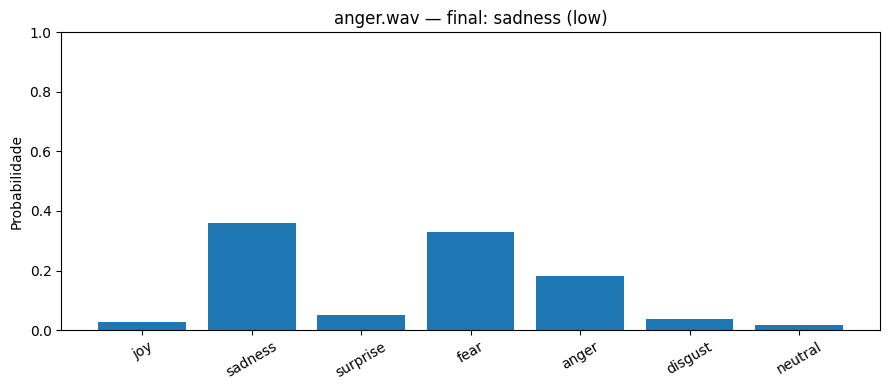

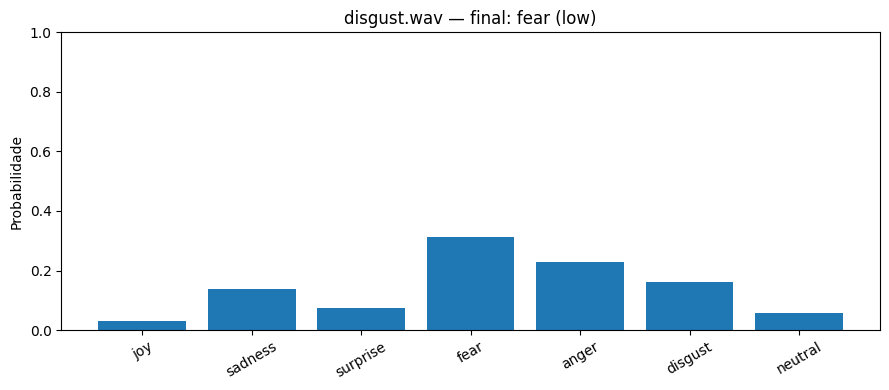

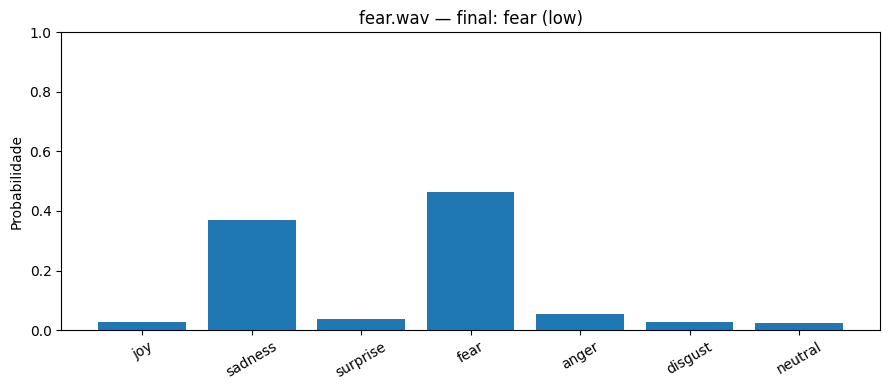

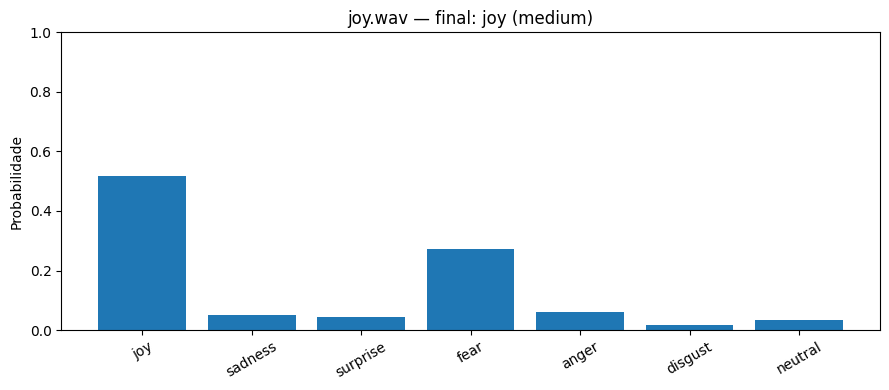

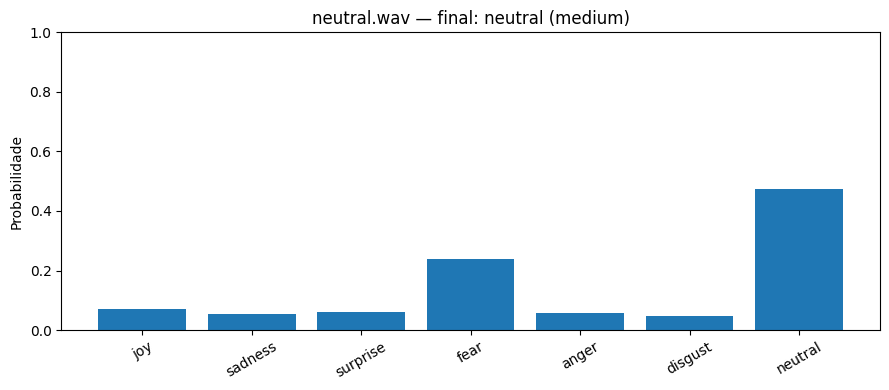

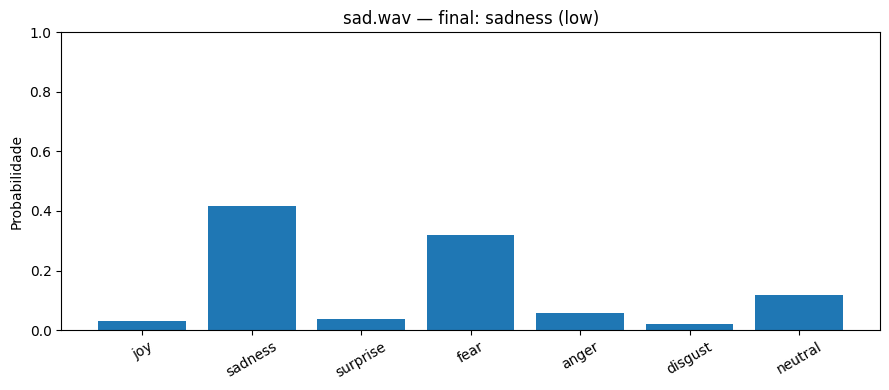

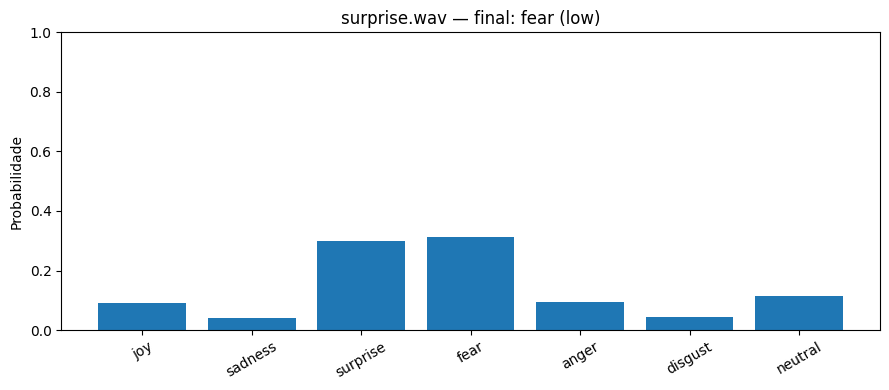

In [69]:
# ============================================================
# 14. Visualizar distribuições finais
# ============================================================


def plot_distribution(dist: Dict[str, float], title: str):
    labels = EMOTIONS
    values = [float(dist.get(e, 0.0)) for e in labels]
    plt.figure(figsize=(9, 4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("Probabilidade")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if "all_results" in globals() and all_results:
    for r in all_results:
        plot_distribution(r["final_distribution"], f"{r['file']} — final: {r['dominant_emotion']} ({r['confidence_level']})")
else:
    print("Sem resultados para visualizar.")


## Interpretação recomendada no relatório

A fusão final mantém-se como **late fusion adaptativa**, mas o módulo de prosódia passa a ser mais forte.

Justificação:

- o texto continua a ser a modalidade principal, porque a transcrição contém informação semântica direta;
- a prosódia passa a combinar um ramo clássico interpretável com um ramo moderno baseado em embeddings de fala pré-treinados;
- como não existe um dataset multimodal emparelhado grande, não se treina stacking, intermediate fusion ou attention-based fusion;
- os pesos são calculados por amostra com base na confiança das distribuições, qualidade do áudio, qualidade da transcrição e desempenho empírico de cada modalidade;
- a saída final é sempre uma distribuição completa pelas 7 emoções, não apenas uma classe dominante.

Formulação curta:

> A arquitetura final usa uma estratégia de late fusion adaptativa entre o classificador textual e o classificador acústico. O módulo acústico foi reforçado com embeddings auto-supervisionados de fala, usados como extratores congelados, e combinado com features prosódicas manuais. A decisão multimodal final resulta da média ponderada das distribuições, com pesos ajustados dinamicamente pela incerteza e pela fiabilidade estimada de cada modalidade.